**Following guidelines set expectations for participant behaviour during workshop activities. They also ensure that the class environment is welcoming, inclusive, and respectful.**
- Where a discussion is taking place, allow everyone a chance to speak
- Listen respectfully, without interrupting and with an open mind to understanding others’ views
- Be professional and productive, and always share your ideas, your opinion matters, we all can learn something from each other
- Personal information that comes up in the conversation should be kept confidential
- Avoid inflammatory language
- Avoid assumptions about any member of the class or generalisations about social groups

**You have now joined a group of fellow analysts in a workshop:**
#### Outcomes:

- To be able to answer the questions to test your knowledge of Linear Regression

#### Note:
- We understand learners will progress at their own speed
- Tutors will be on hand to answer questions

# ✅ Supervised Learning with Linear Regression - Practical

**Aims of this practical:**
- Understand **supervised learning** and **linear regression** in machine learning.  
- Perform **train-test splitting** for model evaluation.  
- Apply **L1 (Lasso) and L2 (Ridge) regularization** techniques.  
- Evaluate model performance using **R-squared** and **Mean Squared Error (MSE)**. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

**Lasso regression is more robust to outliers in the data than linear regression.**

Here's a Python script to generate a simple dataset with 100 data points, with few outliers, to compare the performance of Lasso regression vs. Linear regression to test Lasso's robustness to outliers.

In [2]:
np.random.seed(46)
n_samples = 100
X = np.linspace(0, 1, n_samples)
y = 2*X + 0.7*np.random.randn(n_samples)

# add some outliers to the dataset
outliers_indices = [60, 65, 70, 75, 80, 45, 50, 61]
y[outliers_indices] = y[outliers_indices] + 16

In [3]:
X[:5]  # Displaying the first five observations of the explanatory variable


array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404])

In [4]:
y[:5]  # Displaying the first five observations of the target variable


array([ 0.40941309,  0.88203904,  0.61573423, -0.49885379,  0.36924534])

Create a scatterplot with `plt.scatter` to visualise the data and all the outliers

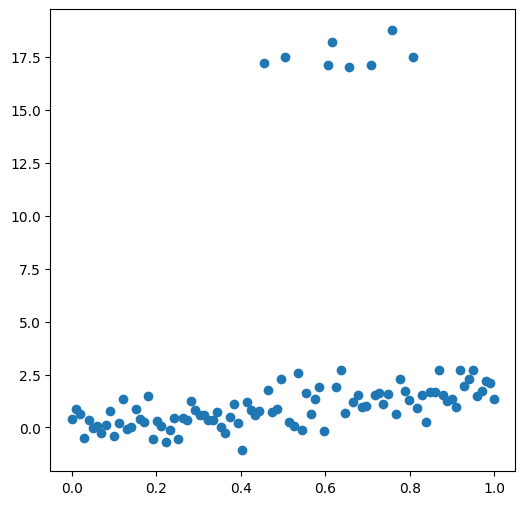

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.show()

#### 🔸 Fitting a Standard Linear Regression Model

Use `LinearRegression` and run `.fit()` to determine the optimal parameters for standard linear regression.  

- Remember to use `X.reshape(-1, 1)` since we only have **one explanatory variable**, ensuring compatibility with `sklearn`.  

- This trains the model on the given data, allowing it to learn the relationship between `X` and `y`.

In [6]:
lr = LinearRegression()
lr.fit(X.reshape(-1, 1), y)

LinearRegression()

Create a scatter plot of the observation in the data and plot the predictions. 
- Use `.predict()` to obtain the predictions for each observation in the data set.
- Remember to use `X.reshape(-1,1)` because we only have 1 explanatory varaible.

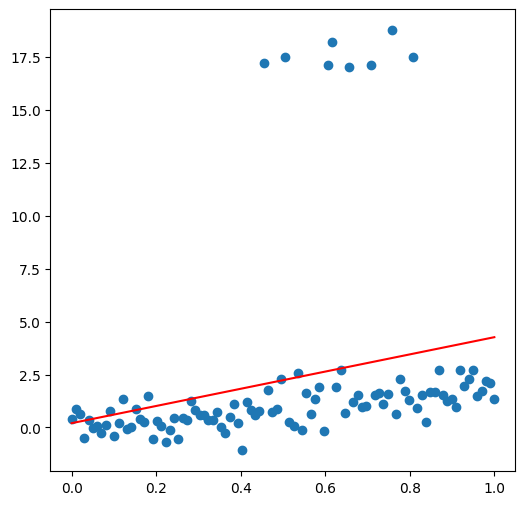

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.plot(X, lr.predict(X.reshape(-1, 1)), color='red')
plt.show()

📌 We can see that the standard linear regression model is pulled towards the outliers. 

#### 🔸 Fitting a Standard Lasso Regression Model

We can apply Lasso regression with an additional penalty term to improve the fit of this model.
- Use `Lasso` from `sklearn` and run `.fit()` to obtain the oprimal parameters.
- Set the regularisation term $\lambda$ as parameter `aplha=0.1`
- Remember to use `X.reshape(-1,1)` because we only have 1 explanatory varaible.

Refer to the syntax below for guidance:
```python
lasso = Lasso(alpha=0.1)
lasso.fit(X.reshape(-1, 1), y)
```

In [8]:
# Your code here


Let's visualise the results of both the linear and the lasso regression model predictions on the entire data set.

NameError: name 'lasso' is not defined

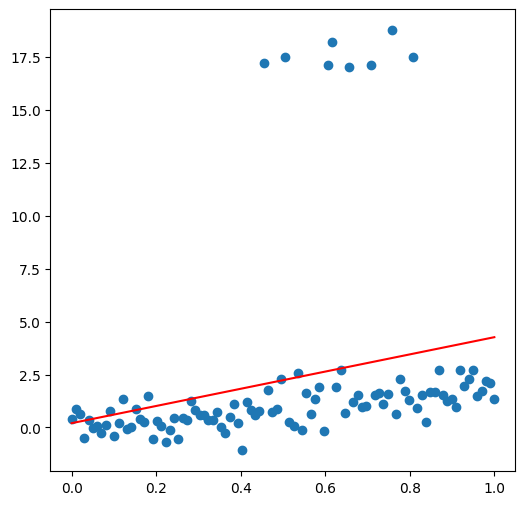

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.plot(X, lr.predict(X.reshape(-1, 1)), color='red', label='Linear Regression')
plt.plot(X, lasso.predict(X.reshape(-1, 1)), color='green', label='Lasso Regression')
plt.legend()
plt.show()

📌 We can see that Lasso regression predictions are more robust against outliers.

Change the strength of the regularisation term $\lambda$ to `alpha=2`.
- What do you observe when you create the same scatter plot with the new Lasso regression model?

Refer to the syntax below for guidance:
```python
lasso = Lasso(alpha=2)
lasso.fit(X.reshape(-1, 1), y)
```

In [ ]:
# Your code here


In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.plot(X, lr.predict(X.reshape(-1, 1)), color='red', label='Linear Regression')
plt.plot(X, lasso.predict(X.reshape(-1, 1)), color='green', label='Lasso Regression')
plt.legend()
plt.show()

📌 The regularisation parameter $\lambda$ controls the strength of the regularisation applied. 

# ✅ Example: Comparing Linear, Ridge, and Lasso Regression in `sklearn`

For the next example we'll use data from `sklearn`: California Housing dataset and apply linear , lasso and ridge regression. We will also evaluate these models based on the MSE of the test set.

#### Data information

- Number of observations: 20640
- Target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).
- Number of explanatory variables: 8 numeric, predictive attributes and the target

- Attribute Information:
            - MedInc        median income in block group
            - HouseAge      median house age in block group
            - AveRooms      average number of rooms per household
            - AveBedrms     average number of bedrooms per household
            - Population    block group population
            - AveOccup      average number of household members
            - Latitude      block group latitude
            - Longitude     block group longitude

📌 This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

We've provided a copy of the dataset in the `data/` folder, let's load it with pandas:

In [ ]:
df = pd.read_csv("data/housing.csv")

You can run `.head()`, `.describe()` and `.info()` to get an overview of the data

In [ ]:
df.head()

We drop the target variable `PRICE` from the explanatory variables and create a test/train dataset split of 20%/80%:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Price', axis=1),
    df['Price'],
    test_size=0.2,
    random_state=42
)

We can view the number of observations per split with `.shape`

In [ ]:
print('Training input data Shape:', X_train.shape)
print('Training output data Shape:', y_train.shape)
print('Testing input data Shape:', X_test.shape)
print('Testing output data Shape:', y_test.shape)

#### Training Linear, Ridge, and Lasso Regression Models

Call `LinearRegression`, `Ridge`, and `Lasso`, and run `.fit()` on the **training set** for each model.  

- The code for `LinearRegression` and `Ridge` is provided. Complete the `Lasso` implementation.  
- Set the **regularisation parameter** (`alpha=1.0`) for both **Ridge** and **Lasso** regression.  

Use the syntax below as a reference:  
```python
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
```

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Your code here
# Add Lasso implementation


We can view the coefficients for the linear, ridge and lasso regression to compare
- We add the column names for the explanatory variables with `.columns`
- We add the model name as the index

In [ ]:
pd.DataFrame([lr.coef_, ridge.coef_, lasso.coef_],
             index=['linear','ridge', 'lasso'],
             columns=df.drop('Price', axis=1).columns)

We can see that lasso regression shrunk `AveRooms`, `AveBedrms`, `AveOccup`, `Latitude` and `Longitude` all the way to 0.

Let's create predictions for the test set for each model and calculate the $R^2$ score and the MSE
- We will use `mean_squared_error` and `r2_score` from `sklearn.metrics`
- Linear and ridge regression has been set up and all that's left is to add lasso regression

In [ ]:
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

Let's print out the results for each model

In [ ]:
print("Linear Regression MSE: {:.3f}, R-squared: {:.3f}".format(mse_lr, r2_lr))
print("Ridge Regression MSE: {:.3f}, R-squared: {:.3f}".format(mse_ridge, r2_ridge))
print("Lasso Regression MSE: {:.3f}, R-squared: {:.3f}".format(mse_lasso, r2_lasso))

The Lasso regression with $\lambda=1$ did not perform as well on this data set.

# ✅ Example: Implementing RandomForestRegressor in `sklearn`

Another regression technique available in `sklearn` is **Random Forest Regression**:  

- It is an **ensemble learning** method that combines multiple **decision trees** to improve predictions.  
- The model leverages **multiple decision trees** working together to enhance accuracy and reduce overfitting.  
- You will learn more about **decision trees** in your next workshop.  
- Simply run the code blocks below to see how it is implemented. 🚀

In [ ]:
from sklearn.ensemble import RandomForestRegressor

We can run the model with the exact same functions as linear regression
- we still use `.fit()` to get the optimal parameters

In [ ]:
# Instantiate model
rf = RandomForestRegressor()

# Train the model on training data
rf.fit(X_train, y_train)

We can run the model with the exact same functions as linear regression
- we still use `.predict()` to get the predictions for the test set

In [ ]:
# Use the forest's predict method on the test data
y_pred_randomf = rf.predict(X_test)

We can run the model with the exact same functions as linear regression
- we still use `.mean_squared_error()` to obtain the MSE for the test set

In [ ]:
mse_randomf = mean_squared_error(y_test, y_pred_randomf)
print(mse_randomf)

📌 The **Mean Squared Error (MSE)** is significantly lower for the **Random Forest Regression** model compared to **Linear, Ridge, and Lasso Regression** models, indicating better predictive performance.

**Use Random Forest Regression** when the data has **non-linear relationships**, **many features**, or **complex interactions** between variables. It is also more **robust to outliers** and **less prone to overfitting** compared to Linear, Ridge, and Lasso Regression.  

**Use Linear, Ridge, or Lasso Regression** when the relationship between features and the target is **linear**, the dataset is **small or interpretable**, or when you need **feature selection** (Lasso) or **regularization** (Ridge) to prevent overfitting.